<a href="https://colab.research.google.com/github/Josep1990/data-preparation-for-finance/blob/data-preparation-basics/preparing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from datetime import datetime
from sys import exit
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

os.makedirs("models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)





In [2]:
df = pd.read_csv(f'BTCUSDT-15m-data.csv')
print(df.head())

             timestamp      open_time     open     high      low    close  \
0  2017-08-17 04:00:00  1502942400000  4261.48  4280.56  4261.48  4261.48   
1  2017-08-17 04:15:00  1502943300000  4261.48  4270.41  4261.32  4261.45   
2  2017-08-17 04:30:00  1502944200000  4280.00  4310.07  4267.99  4310.07   
3  2017-08-17 04:45:00  1502945100000  4310.07  4313.62  4291.37  4308.83   
4  2017-08-17 05:00:00  1502946000000  4308.83  4328.69  4304.31  4304.31   

      volume     close_time      quote_av  trades  tb_base_av   tb_quote_av  \
0   2.189061  1502943299999   9333.620962       9    0.489061   2089.104962   
1   9.119865  1502944199999  38891.133046      40    3.447113  14703.934995   
2  21.923552  1502945099999  94080.917568      58   20.421317  87620.977876   
3  13.948531  1502945999999  60060.466816      64   10.803012  46538.460109   
4   5.101153  1502946899999  22006.533111      44    3.496635  15093.783057   

   ignore  
0       0  
1       0  
2       0  
3       0  
4 

In [3]:
df.describe()

df.count()

,0
timestamp,276000
open_time,276000
open,276000
high,276000
low,276000
close,276000
volume,276000
close_time,276000
quote_av,276000
trades,276000


In [4]:
df.tail()

,timestamp,open_time,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
275995,2025-07-07 00:00:00,1751846400000,109203.85,109273.07,109103.19,109273.06,56.48447,1751847299999,6.166301e+06,26415,26.22332,2.862917e+06,0
275996,2025-07-07 00:15:00,1751847300000,109273.07,109288.02,108972.69,109004.81,75.36437,1751848199999,8.220317e+06,24191,33.56157,3.660548e+06,0
275997,2025-07-07 00:30:00,1751848200000,109004.81,109037.82,108829.17,108847.16,76.72080,1751849099999,8.357724e+06,21368,33.08997,3.605029e+06,0
275998,2025-07-07 00:45:00,1751849100000,108847.17,108922.00,108800.01,108823.07,45.06548,1751849999999,4.906468e+06,15579,22.76836,2.478881e+06,0
275999,2025-07-07 01:00:00,1751850000000,108823.07,108823.08,108679.75,108767.01,75.71845,1751850899999,8.232864e+06,22928,38.85713,4.224608e+06,0


In [5]:
print(df.isnull())
print(f'Counts how many missing values there are in each column: {df.isnull().sum()}')
print(f'Total missing values: {df.isnull().sum().sum()}')

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

#Training Phase

Splitting data to train/test sets

Practice same pattersn multiple times

Have access to answer key

problems known:
Overfitting
Underfitting

#Testing Phase

Face new Patterns

No access to asnwer key


In [6]:
train_end_idx = 240_000

df_train = df.iloc[:train_end_idx].copy()

df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

# Instead o preprocessing the data set first
# we split it and then preprocess
# this way we can ensure the test data do not leak into the training data

print(f'Length of training set: {len(df_train)}')
print(f'Length of testing set: {len(df_test)}')

Length of training set: 240000
Length of testing set: 36000


In [7]:
# what is a feature:
# a Mesurable piece of information that describe the data
# help the model to recognize patterns

#always pay attention to the shape of the data

def build_feature(opens, highs, lows, closes, volumes, train_scalers=None):
  #build features
  feature1 = (closes - opens) / opens
  feature2 = (highs - opens) / opens # how much price rose above the open
  feature3 = (highs - closes) / closes # how far the close was below the high
  feature4 = (lows - opens) / opens # how much price fell below the open
  feature5 = (lows - closes) / closes # how far the close was above the low
  feature6 = (highs - lows) / opens # the day's volatility range relative to open
  feature7 = (highs - lows) / closes # the day's volatility range relative to close
  feature8 = volumes

  ### Trim Outliers
  # def trim_outliers(x, threshold):
  #   x = np.minumun(x, threshold) # cap upper bound
  #   x = np.maximum(x, -threshold) # cap lower bound
  #   return x

  # fearure1 = trim_outliers(fearure1, 0.1)
  # feature2 = trim_outliers(feature2, 0.1)
  # feature3 = trim_outliers(feature3, 0.1)
  # feature4 = trim_outliers(feature4, 0.1)
  # feature5 = trim_outliers(feature5, 0.1)
  # feature6 = trim_outliers(feature6, 0.1)
  # feature7 = trim_outliers(feature7, 0.1)
  # feature8 = trim_outliers(feature8, 2000)


  # Stack features
  features = [
      feature1,
      feature2,
      feature3,
      feature4,
      feature5,
      feature6,
      feature7,
      feature8,
  ]
  num_features = len(features)
  scaled_fts = []

  if train_scalers is None:
      train_scalers = [MaxAbsScaler() for _ in range(num_features)]
      is_train = True
  else:
      is_train = False

  for i in range(num_features):
      # Get train scaler
      scaler = train_scalers[i]
      if is_train:
          # Scaler -> Fit -> Train dataset
          #Training Mode:
          # "fit_transform" -> learn the max value from training data
          # and then scale the feature accorndignly
          scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
          # Save the train scaler in a list
      elif not is_train:
          # Scaler -> NOT Fit -> Test dataset
          #Testing Mode:
          #"transform" -> DO Not re-learn!
          # Just use the max value found in training to scale this test feature
          scaled_ft = scaler.transform(features[i].reshape(-1, 1))

      # Update list of SCALED features
      scaled_fts.append(scaled_ft.flatten())

  # Stack features
  scaled_features = np.stack(scaled_fts, axis=-1)

  # Get num. features
  num_features = scaled_features.shape[-1]
  return scaled_features, num_features, train_scalers

In [8]:
def preprocessing_data(seq_len, df, train_scalers=None):
  m =len(df)

  opens = np.array(df['open'].values)
  highs = np.array(df['high'].values)
  lows = np.array(df['low'].values)
  closes = np.array(df['close'].values)
  volumes = np.array(df['volume'].values)

  # Build features
  features, num_features, train_scalers = build_feature(opens, highs, lows, closes, volumes, train_scalers)

  # calculate number of samples
  num_samples = m - seq_len

  #create storage for input & targets
  # x the input sequence
  # y the output/target
  X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
  Y = np.zeros([num_samples, num_features], dtype=np.float32)

  for i in range(num_samples):
    X[i] = features[i:i+seq_len]
    Y[i] = features[i+seq_len : i+seq_len+1]

  # FIX alignment
  opens = np.array(opens[seq_len:])
  closes = np.array(closes[seq_len:])

  return X, Y, num_features, opens, closes, train_scalers

In [9]:
from re import X
# Sequence Lenght fot the inout sequence equivalent 1 day of 15m candles
seq_len = 96

# Processing data
X_train, Y_train, num_features, _, _, train_scalers = preprocessing_data(seq_len, df_train)
X_test, Y_test, num_features, backtest_opens, backtest_closes, _ = preprocessing_data(seq_len, df_test, train_scalers)

m_train = X_train.shape[0]
m_test = X_test.shape[0]


print(f'Number of training samples (m_train): {m_train}')
print(f'Number of testing samples (m_test): {m_test}')
print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')

Number of training samples (m_train): 239904
Number of testing samples (m_test): 35904
X_train shape: (239904, 96, 8)
Y_train shape: (239904, 8)
X_test shape: (35904, 96, 8)
Y_test shape: (35904, 8)


In [10]:
# pytorch models can only work with tensors

# pytorch and tensorFlow

#what is a tensor: a similar to a numpy array, but it can be on a cpu

# pytorch works best with float 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("my device: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)


my device:  cpu


In [16]:
import numpy as np

#dot product caluculation
x = 82
W_h1 = 0.35
b_h1 = 52

W_h2 = 0.68
b_h2 = 12

W_out = [0.75, 0.46]
b_out = 37

h1 = x * W_h1 + b_h1
h2 = x * W_h2 + b_h2
H = [h1, h2]

Y_hat = np.dot(H, W_out) + b_out
print(f'Prediction: {Y_hat}')



Prediction: 128.6946


In [17]:
class Model(nn.Module):
    def __init__(self):
       super().__init__()

       self.conv1 = nn.Conv1d(
           in_channels=num_features,
           out_channels=32,
           kernel_size=3,
           stride=1,
           padding=1 # default to 0 but add 1, investigate - padding help control the output shape
       )

       self.act1 = nn.GELU()

       self.conv2 = nn.Conv1d(
           in_channels=32,
           out_channels=64,
           kernel_size=3,
           padding=1 # default to 0 but add 1, investigate - padding help control the output shape
       )

       self.act2 = nn.GELU()

       self.fc_out = nn.Linear(64 * seq_len, num_features)

    def forward(self, x):
        # x shape: (batch_size, seq_len, num_features)
        x = x.permute(0, 2, 1) # (batch, num_feature, seq_len)

        # Conv block 1
        x = self.conv1(x)  # (batch, 32, seq_len)2
        x = self.act1(x)

        # Pass to Workstation 2
        # Conv block 1
        x = self.conv2(x)  # (batch, 64, seq_len)
        x = self.act2(x)

        x = x.permute(0, 2, 1) # (batch, seq_len, num_feature)
        x = x.reshape(-1, 64 * seq_len)
        # x = x[:, -1, :]

        # Get final output
        x = self.fc_out(x) # (batch, num_feature)

        return x


In [12]:
# class Model(nn.Module):
#     def __init__(self):
#        super().__init__()

#        #work station 1:
#        # fc stand to fully connect layer typically linear
#        self.fc1 = nn.Linear(in_features=seq_len * num_features, out_features = 32)
#        self.act1 = nn.ReLU()

#        #word station 2:
#        self.fc2 = nn.Linear(in_features=32, out_features = 64)
#        self.act2 = nn.ReLU()

#        #word station 3:
#        self.fc3 = nn.Linear(in_features=64, out_features = 128)
#        self.act3 = nn.ReLU()

#        #word station 4:
#        self.fc4 = nn.Linear(in_features=128, out_features = 256)
#        self.act4 = nn.ReLU()

#        #Head Manager:
#        self.fe_out = nn.Linear(in_features=256, out_features = num_features)


#     def forward(self, x):
#         # x shape: (batch_size, seq_len, num_features)
#         x = x.reshape(-1, seq_len*num_features)

#         # Pass to Workstation 1
#         x = self.fc1(x)
#         x = self.act1(x)

#         # Pass to Workstation 2
#         x = self.fc2(x)
#         x = self.act2(x)

#         # Pass to Workstation 3
#         x = self.fc3(x)
#         x = self.act3(x)

#         # Pass to Workstation 4
#         x = self.fc4(x)
#         x = self.act4(x)

#         # Get final output
#         x = self.fe_out(x)

#         return x

In [18]:
# Initialize model
model = Model()

# Transfer model to device
model.to(device)

# Initialize criterion (convention name for loss function)
# Mean Square Error
criterion = nn.MSELoss()

# Choose learning rate
lr = 1e-4

# Create optimizer
# Adam optmizer \ lr = learming rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Choose batch size
# 32 stable and nice speed
batch_size = 32

# Lists of train/test losses
train_losses = []
test_losses = []

equity_epochs = []
accuracy_epochs = []

# Set epoch
num_epochs = 200

In [19]:
def create_minibatches(X, Y, batch_size, seed, shuffle=True):
    mini_batches = []
    m = len(X)

    if shuffle:
        permutation = list(np.random.permutation(m))
        X = X[permutation]
        Y = Y[permutation]

    num_batches = m // batch_size

    for k in range(num_batches):
        mb_X = X[k * batch_size : k * batch_size + batch_size]
        mb_Y = Y[k * batch_size : k * batch_size + batch_size]
        mb_pair = (mb_X, mb_Y)
        mini_batches.append(mb_pair)

    seed += 1
    set_all_seeds(seed)

    return mini_batches, seed

In [22]:
def load_training_data(model, optimizer):
  checkpoint = torch.load('training_process', weights_only=False)
  epoch = checkpoint['epoch']
  train_losses = checkpoint['train_losses']
  test_losses = checkpoint['test_losses']
  equity_epochs = checkpoint['equity_epochs']
  accuracy_epochs = checkpoint['accuracy_epochs']
  seed = checkpoint['seed']

  #Load models weights & optimizer's state
  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

  return model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed


if os.path.exists('training_process'):
  model, optimizer, epoch, train_losses, test_losses, equity_epochs, accuracy_epochs, seed = load_training_data(model, optimizer)
  print(f'Loaded Model: {model}')
else:
  print('No training process to load.')

No training process to load.


Epoch: 0, Equity: 283.35, Accuracy: 49.95 train_losses: 0.0003607304847405608, test_losses: 0.00011100867413915694, Duration: 0:01:24.219781


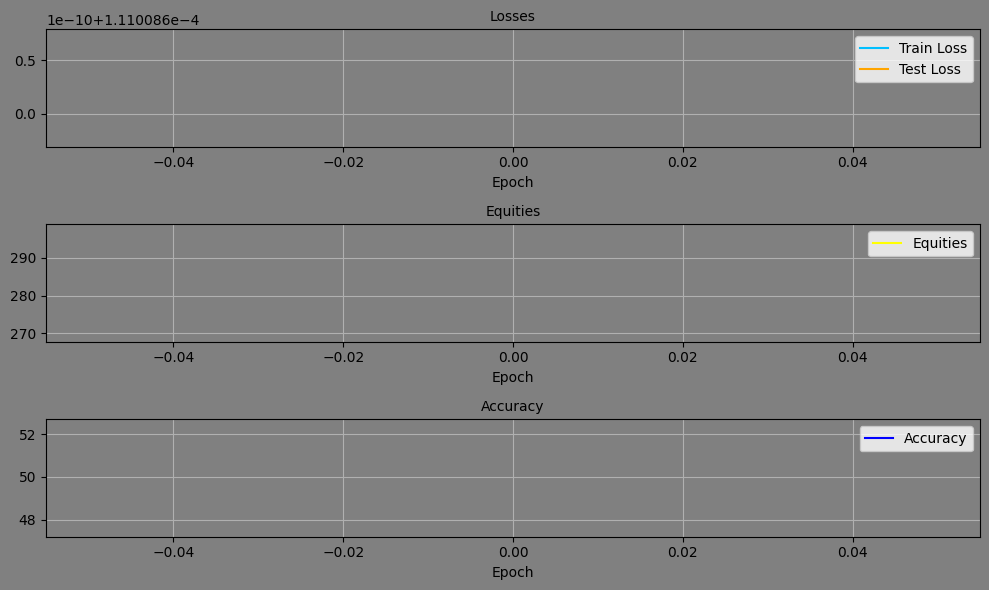

Epoch: 1, Equity: 1958.90, Accuracy: 50.12 train_losses: 0.0003001937718247211, test_losses: 0.00010286586621077731, Duration: 0:01:22.505239


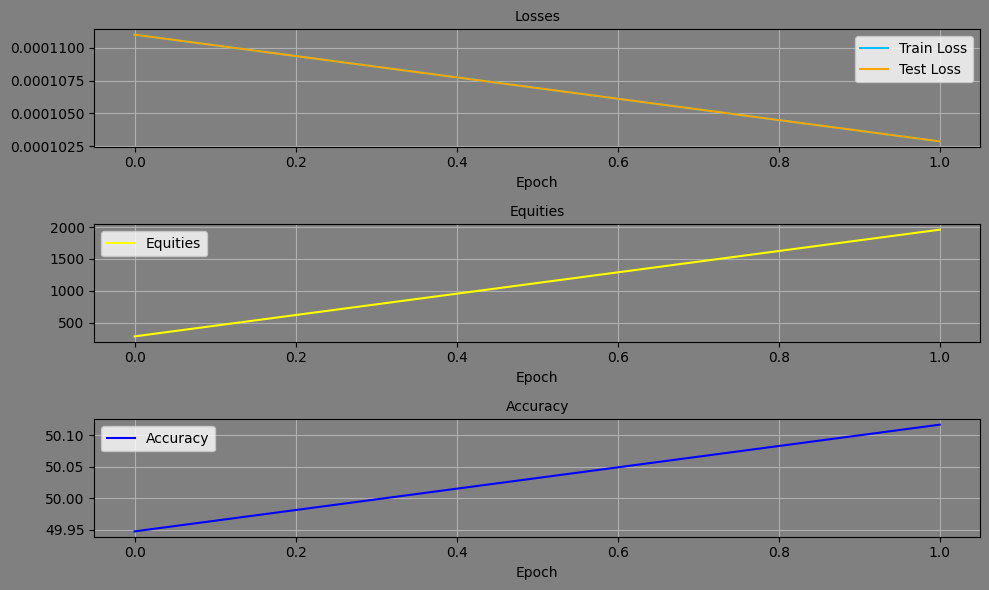

KeyboardInterrupt: 

In [23]:
for epoch in range(num_epochs):
    # Track duration
    dt0_epoch = datetime.now()

    # Create mini batches
    mini_batches, seed = create_minibatches(X_train, Y_train, batch_size, seed, shuffle=True)

    train_losses_batch = []

    for X_train_batch, Y_train_batch in mini_batches:
        # Set train mode
        model.train()

        # Reset the gradients
        optimizer.zero_grad()

        # Forward propagation
        Y_hat_train = model(X_train_batch) # Shape: (batch_size, num_features)

        # Calculate loss (train)
        train_loss = criterion(Y_hat_train, Y_train_batch)

        # Backprop
        train_loss.backward()

        # Update optimizer
        optimizer.step()

        # Keep track of training losses
        train_losses_batch.append(train_loss.item())

    # Predict on test data
    with torch.no_grad():

        # Set evaluation mode
        model.eval()

        # Forward propagation
        Y_pred_test = model(X_test)

        # Calculate test loss
        test_loss = criterion(Y_pred_test, Y_test)

    # Convert 'Y_pred_test' to numpy
    Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()

    train_losses.append(np.mean(train_losses_batch))
    test_losses.append(test_loss.item())

    #==================== Backtest ====================
    equities = [] #Store equity (account value) over time
    pos_size = 1000 # Fixed position size ($1000 per trade)
    equity = 1000 # starting capital
    correct_pred = 0 # Store correct precisions

    # Y_pred_test_cpu is 2d numpy array, the first dimension n of symnbols and
    # second dimentsion is number of features, the colon means we take every roll
    # the zero index means we take first colunm
    # the bigger than 0 gets compared to 0 True is biiger and False is lower
    # True is buy and False is sell
    actions = Y_pred_test_cpu[:,0] > 0 # Get the model's buy/sell predictions

    for i in range(len(X_test)-1):
      curr_open = backtest_opens[i] # the price we entered at
      curr_close = backtest_closes[i] # the price we exit at
      curr_action = actions[i] # the model's signal (buy or sell).

      #Calculate percentage price change
      # how price movend compared with the entry price
      pct_change = (curr_close - curr_open) / curr_open

      #Profit or Loss in dollars
      pnl = np.abs(pos_size * pct_change)

      #Update equity dependeing on action and price move
      if curr_action == 1: #Long Position - buy side
        if pct_change > 0:
          equity += pnl #price up -> profit
          correct_pred += 1
        elif pct_change < 0:
          equity -= pnl #price down -> loss

      elif curr_action == 0: #Short Position - sell side
        if pct_change > 0:
          equity -= pnl #price up -> loss
        elif pct_change < 0:
          equity += pnl #price down -> profit
          correct_pred += 1

      equities.append(equity) #save current equity

  # ==================================================
    accuracy = correct_pred / len(X_test) * 100

    # Save final equity for each epoch
    equity_epochs.append(equity)
    accuracy_epochs.append(accuracy)

    # ========== backtest end =======================


    print(f'Epoch: {epoch}, Equity: {equity:.2f}, Accuracy: {accuracy:.2f} train_losses: {train_losses[-1]}, test_losses: {test_losses[-1]}, Duration: {datetime.now() - dt0_epoch}')

    # Save training process
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'equity_epochs': equity_epochs,
        'accuracy_epochs': accuracy_epochs,
        'seed': seed,
        }, 'training_process')

    if equity > 3000:
      torch.save(model.state_dict(), f'models/eq_{equity:.0f}_ep_{epoch}.pt')


    #Plot training process
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,6))
    scaler_testloss = MinMaxScaler(feature_range=(np.min(test_losses)-0.0000000001, np.max(test_losses)))

    # Plot Train Loss and Test Loss
    axs[0].set_title(f"Losses", fontsize=10)
    axs[0].plot(scaler_testloss.fit_transform(np.array(train_losses).reshape(-1,1)), label='Train Loss', color='deepskyblue')
    axs[0].plot(test_losses, label='Test Loss', color='orange')
    axs[0].set_xlabel("Epoch")
    axs[0].legend()
    axs[0].grid()
    # Plot Equities
    axs[1].set_title(f"Equities", fontsize=10)
    axs[1].plot(equity_epochs, label='Equities', color='yellow')
    axs[1].set_xlabel("Epoch")
    axs[1].legend()
    axs[1].grid()
    # Plot Accuracy
    axs[2].set_title(f"Accuracy", fontsize=10)
    axs[2].plot(accuracy_epochs, label='Accuracy', color='blue')
    axs[2].set_xlabel("Epoch")
    axs[2].legend()
    axs[2].grid()
    # Set background color and paper color
    fig.patch.set_facecolor(mcolors.to_hex('grey'))  # Set paper color
    for ax in axs.flat:
        ax.set_facecolor(mcolors.to_hex('grey'))  # Set bg color
    # Display
    plt.tight_layout()
    plt.savefig(f'training_process.png')
    plt.show()
    plt.close()